# Predicting F1 Pit Stops
**Kaggle Playground Series S6E5**: predict the probability that a driver pits on the next lap (`PitNextLap`).

- **Metric:** ROC-AUC. Only the ranking of the predicted probabilities matters.
- **Data:** 439k training and 188k test laps, generated synthetically from the
  [F1 Strategy Dataset](https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction)
  (101k real laps from the FastF1 library, called the *original* dataset below).
- **Approach**, taken from the winning write-ups and the strongest public notebooks:
  1. append the original laps to every training fold, the one idea every top team agreed on;
  2. race-length and tyre-wear features (`LapNumber / RaceProgress` recovers the race's total laps);
  3. count encoding plus fold-safe target encoding of race, compound, stint and driver keys;
  4. LightGBM, LightGBM without driver features, XGBoost and CatBoost on the same 5 folds;
  5. a logistic-regression stack on the models' out-of-fold logits.

The competition closed on 31 May 2026. The submission at the end is a late submission, which Kaggle still
scores on both the public and private leaderboards.

In [1]:
import io, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

COMP = 'playground-series-s6e5'
SEED = 42
N_FOLDS = 5
TARGET = 'PitNextLap'

# Plot styling: fixed categorical slots, recessive grid
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.edgecolor': '#9a9994', 'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9,
    'lines.linewidth': 2,
})

## 1. Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# Original dataset. The author's copy (aadigupta1601/f1-strategy-dataset-pit-stop-prediction) can no longer be
# downloaded through the API, so this reads a mirror of the same f1_strategy_dataset_v4.csv:
#   kaggle datasets download vanshjasuja16/f1-strategy-dataset-pit-stop-prediction -p original --unzip
orig = pd.read_csv('original/f1_strategy_dataset_v4.csv')
orig = orig.drop(columns=['Normalized_TyreLife'])   # Kaggle removed it from the competition data: it makes the task trivial
print('train', train.shape, '| test', test.shape, '| original', orig.shape)
train.head()

train (439140, 16) | test (188165, 15) | original (101371, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 2. EDA
### 2.1 Structure and missing values

In [3]:
CATS = ['Driver', 'Compound', 'Race']
NUMS = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
        'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
FEATURES = CATS + NUMS

summary = pd.DataFrame({
    'dtype': train[FEATURES].dtypes.astype(str),
    'n_unique': train[FEATURES].nunique(),
    'n_unique_original': orig[FEATURES].nunique(),
    'train_missing': train[FEATURES].isna().sum(),
    'original_missing': orig[FEATURES].isna().sum(),
})
display(summary)
print(f'Pit-next-lap rate: train {train[TARGET].mean():.2%} | original {orig[TARGET].mean():.2%}')
print(f"Train rows whose driver code exists in the original: {train['Driver'].isin(orig['Driver']).mean():.1%}")

,dtype,n_unique,n_unique_original,train_missing,original_missing
Driver,str,887,31,0,0
Compound,str,5,5,0,66
Race,str,26,28,0,0
Year,int64,4,4,0,0
PitStop,int64,2,2,0,0
LapNumber,int64,78,78,0,0
Stint,int64,8,8,0,0
TyreLife,float64,78,78,0,0
Position,int64,20,20,0,0
LapTime (s),float64,37719,40779,0,0


Pit-next-lap rate: train 19.90% | original 25.48%
Train rows whose driver code exists in the original: 6.9%


### 2.2 When do drivers pit?

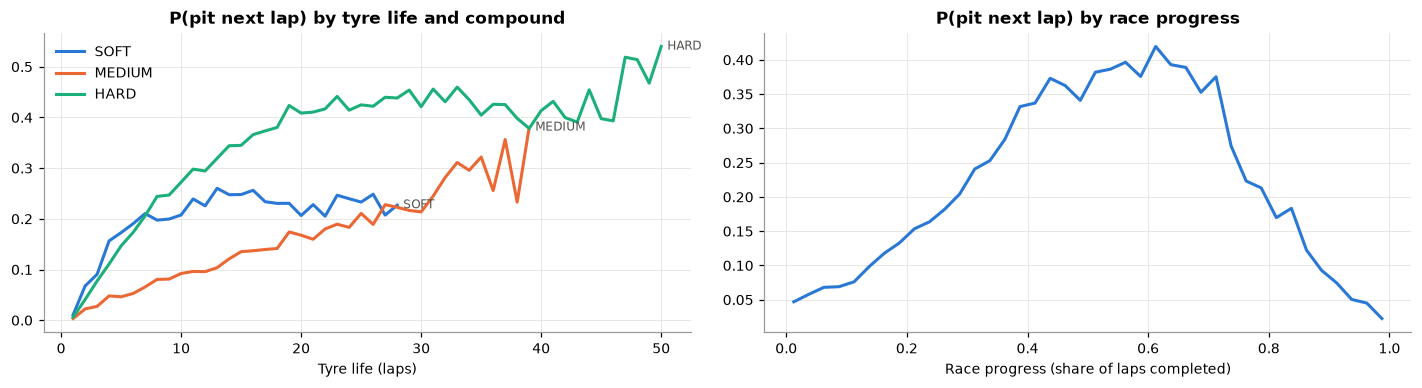

Compound,HARD,INTERMEDIATE,MEDIUM,SOFT,WET
Stint,,,,,
1,0.075,0.100,0.035,0.247,0.020
2,0.384,0.330,0.448,0.196,0.258
3,0.320,0.360,0.278,0.137,NaN
4,0.238,0.037,0.137,0.177,0.000
5,0.122,0.134,0.053,0.026,0.000
6,0.042,0.024,0.000,0.005,0.000
7,0.000,0.000,0.000,0.000,NaN
8,NaN,0.023,0.000,0.000,NaN


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for comp, color in zip(['SOFT', 'MEDIUM', 'HARD'], [BLUE, ORANGE, AQUA]):
    g = train[train['Compound'] == comp].groupby('TyreLife')[TARGET].agg(['mean', 'size'])
    g = g[g['size'] >= 200]
    axes[0].plot(g.index, g['mean'], color=color, label=comp)
    axes[0].annotate(comp, (g.index[-1], g['mean'].iloc[-1]), xytext=(4, 0), textcoords='offset points',
                     va='center', fontsize=8, color='#52514e')
axes[0].set_title('P(pit next lap) by tyre life and compound')
axes[0].set_xlabel('Tyre life (laps)')
axes[0].legend(frameon=False)

prog = pd.cut(train['RaceProgress'], np.linspace(0, 1, 41))
g = train.groupby(prog, observed=True)[TARGET].mean()
axes[1].plot([iv.mid for iv in g.index], g.values, color=BLUE)
axes[1].set_title('P(pit next lap) by race progress')
axes[1].set_xlabel('Race progress (share of laps completed)')
plt.tight_layout(); plt.show()

display(pd.crosstab(train['Stint'], train['Compound'], values=train[TARGET], aggfunc='mean').round(3))

### 2.3 Train vs test, and synthetic vs original (adversarial validation)
A classifier is trained to tell two datasets apart. An AUC near 0.5 means they look the same.

Adversarial AUC train vs test:     0.4985   (~0.5 => same distribution)


Adversarial AUC train vs original: 0.9941


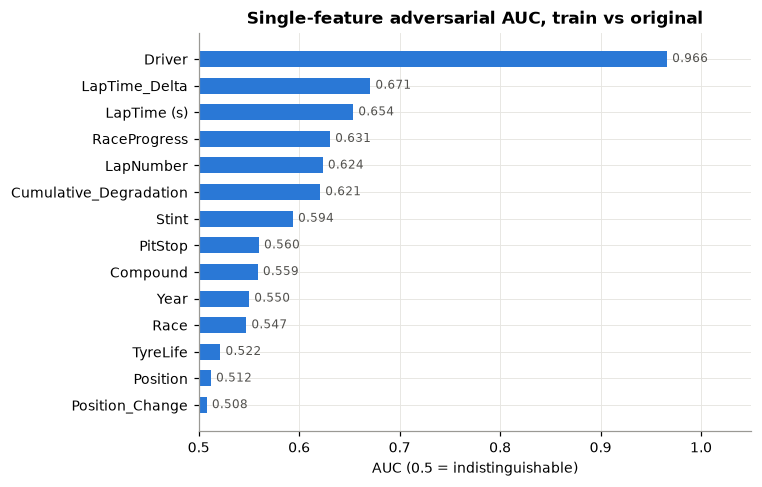

In [5]:
ADV_PARAMS = dict(objective='binary', learning_rate=0.1, num_leaves=63, verbose=-1, n_jobs=-1, seed=SEED)

def adversarial_auc(a, b, cols, n=100_000):
    a = a.sample(min(n, len(a)), random_state=SEED)
    b = b.sample(min(n, len(b)), random_state=SEED)
    Xab = pd.concat([a[cols], b[cols]], ignore_index=True)
    for c in Xab.select_dtypes(exclude='number').columns:
        Xab[c] = Xab[c].astype('category')
    t = np.r_[np.zeros(len(a)), np.ones(len(b))]
    Xa, Xb, ta, tb = train_test_split(Xab, t, test_size=0.3, random_state=SEED, stratify=t)
    m = lgb.train(ADV_PARAMS, lgb.Dataset(Xa, ta), 200)
    return roc_auc_score(tb, m.predict(Xb))

print(f'Adversarial AUC train vs test:     {adversarial_auc(train, test, FEATURES):.4f}   (~0.5 => same distribution)')
print(f'Adversarial AUC train vs original: {adversarial_auc(train, orig, FEATURES):.4f}')

per_feature = pd.Series({c: adversarial_auc(train, orig, [c]) for c in FEATURES}).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(per_feature.index, per_feature.values - 0.5, left=0.5, color=BLUE, height=0.6)
for i, v in enumerate(per_feature.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8, color='#52514e')
ax.set_xlim(0.5, 1.05)
ax.set_title('Single-feature adversarial AUC, train vs original')
ax.set_xlabel('AUC (0.5 = indistinguishable)')
plt.tight_layout(); plt.show()

**EDA takeaways**
- No missing values in the competition data (the original has a few missing `Compound` values).
- Pit probability rises with tyre age and depends strongly on the compound and the stint: these are the core signals.
- Train and test come from the same distribution, so CV should track the leaderboard.
- The original laps are a different population. `Driver` is by far the most different column: the generator
  invented hundreds of synthetic driver IDs (`D001`...) that do not exist in the real data. The 1st-place team
  found that models trained *without* driver features added useful diversity, so one model below drops them.

## 3. Feature engineering
- **Race length:** `RaceProgress = LapNumber / total laps`, so `LapNumber / RaceProgress` recovers the race distance
  in laps, one of the strongest features found in this competition. From it come laps left and tyre age as a share
  of the race.
- **Tyre wear:** tyre life per lap, the lap of the last stop (`LapNumber - TyreLife`), degradation per tyre lap and
  lap-time x degradation interactions (from the top public RealMLP notebook).
- **Keys:** Race x Year, Race x Compound, Compound x Stint, Race x Year x Compound and Driver x Year, used as
  categories and target-encoded.
- **Count encoding:** how often each value or key appears across train, test and original. Synthetic-data
  generators copy values from the source data, so frequency itself carries signal.

In [6]:
COMBOS = [('Race', 'Year'), ('Race', 'Compound'), ('Compound', 'Stint'), ('Race', 'Year', 'Compound'), ('Driver', 'Year')]
KEYS = CATS + ['_'.join(c) for c in COMBOS]
EPS = 1e-6

def as_key(s):
    return s.astype(str).fillna('NA')   # pandas 3 keeps NaN through astype(str)

def make_features(df):
    df = df[FEATURES].copy()
    df['total_laps'] = df['LapNumber'] / (df['RaceProgress'] + EPS)
    df['laps_left'] = df['total_laps'] - df['LapNumber']
    df['tyre_per_lap'] = df['TyreLife'] / df['LapNumber'].clip(lower=1)
    df['tyre_frac_race'] = df['TyreLife'] / (df['total_laps'] + EPS)
    df['stint_start_lap'] = df['LapNumber'] - df['TyreLife']
    df['deg_per_tyre_lap'] = df['Cumulative_Degradation'] / df['TyreLife'].clip(lower=1)
    df['delta_ratio'] = df['LapTime_Delta'] / df['LapTime (s)']
    df['laptime_x_deg'] = df['LapTime (s)'] * df['Cumulative_Degradation']
    df['laptime_x_absdeg'] = df['LapTime (s)'] * df['Cumulative_Degradation'].abs()
    df['laptime_div_absdeg'] = df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + EPS)
    for cols in COMBOS:
        key = as_key(df[cols[0]])
        for c in cols[1:]:
            key = key + '_' + as_key(df[c])
        df['_'.join(cols)] = key
    return df

full = pd.concat([make_features(d) for d in (train, test, orig)], ignore_index=True)
for c in KEYS + ['Year', 'Stint', 'TyreLife', 'LapNumber', 'Position', 'LapTime (s)', 'RaceProgress']:
    full[f'cnt_{c}'] = full[c].map(full[c].value_counts()).astype('float32')
for c in KEYS:
    full[c] = as_key(full[c]).astype('category')

n_tr, n_te = len(train), len(test)
X = full.iloc[:n_tr].reset_index(drop=True)
X_test = full.iloc[n_tr:n_tr + n_te].reset_index(drop=True)
X_orig = full.iloc[n_tr + n_te:].reset_index(drop=True)
y = train[TARGET].astype(int).values
y_orig = orig[TARGET].astype(int).values
del full
print('features:', X.shape[1], '| train', X.shape, '| test', X_test.shape, '| original', X_orig.shape)

features: 44 | train (439140, 44) | test (188165, 44) | original (101371, 44)


## 4. Cross-validated models
Stratified 5-fold CV on the competition rows. The original laps are appended to the **training** part of every fold
only, so validation folds stay pure competition data and the OOF AUC stays honest. Target encoding is fitted inside
each fold on its training rows; scikit-learn's `TargetEncoder` cross-fits those rows internally, so no row sees its
own label. Validation and test rows are encoded with the fold's mapping.

In [7]:
FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
TE_COLS = ['Driver'] + ['_'.join(c) for c in COMBOS]
TE_NAMES = [f'te_{c}' for c in TE_COLS]

def add_target_encoding(Xtr, ytr, others):
    te = TargetEncoder(target_type='binary', smooth='auto', cv=5, shuffle=True, random_state=SEED)
    def attach(d, enc):
        return pd.concat([d.reset_index(drop=True), pd.DataFrame(enc, columns=TE_NAMES)], axis=1)
    Xtr = attach(Xtr, te.fit_transform(Xtr[TE_COLS].astype(str), ytr))
    return Xtr, [attach(d, te.transform(d[TE_COLS].astype(str))) for d in others]

def run_cv(name, fit_predict, use_te=True, use_orig=True):
    oof, pred, t0 = np.zeros(len(X)), np.zeros(len(X_test)), time.time()
    for k, (tr_idx, va_idx) in enumerate(FOLDS):
        Xtr, ytr = X.iloc[tr_idx], y[tr_idx]
        if use_orig:
            Xtr, ytr = pd.concat([Xtr, X_orig], ignore_index=True), np.r_[ytr, y_orig]
        Xva, Xte = X.iloc[va_idx], X_test
        if use_te:
            Xtr, (Xva, Xte) = add_target_encoding(Xtr, ytr, [Xva, Xte])
        oof[va_idx], p = fit_predict(Xtr, ytr, Xva, y[va_idx], Xte)
        pred += p / N_FOLDS
        print(f'  fold {k}: {roc_auc_score(y[va_idx], oof[va_idx]):.5f}')
    score = roc_auc_score(y, oof)
    print(f'{name}: OOF AUC {score:.5f}  ({time.time() - t0:.0f}s)')
    return dict(oof=oof, pred=pred, score=score)

results, importances = {}, []

In [8]:
LGB_PARAMS = dict(objective='binary', metric='auc', learning_rate=0.02, num_leaves=127, min_child_samples=50,
                  feature_fraction=0.6, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                  cat_smooth=20, max_cat_to_onehot=8, verbose=-1, n_jobs=-1, seed=SEED)
DRIVER_RAW = ['Driver', 'Driver_Year']   # ~900 synthetic driver IDs: used through count and target encoding only
DRIVER_ALL = DRIVER_RAW + ['cnt_Driver', 'cnt_Driver_Year', 'te_Driver', 'te_Driver_Year']

def make_lgb(drop, keep_importance=False):
    def fit_predict(Xtr, ytr, Xva, yva, Xte):
        cols = [c for c in Xtr.columns if c not in drop]
        m = lgb.train(LGB_PARAMS, lgb.Dataset(Xtr[cols], ytr), 20000, valid_sets=[lgb.Dataset(Xva[cols], yva)],
                      callbacks=[lgb.early_stopping(300, verbose=False)])
        if keep_importance:
            importances.append(pd.Series(m.feature_importance('gain'), cols))
        it = m.best_iteration
        return m.predict(Xva[cols], num_iteration=it), m.predict(Xte[cols], num_iteration=it)
    return fit_predict

results['lgb'] = run_cv('LightGBM', make_lgb(DRIVER_RAW, keep_importance=True))

  fold 0: 0.95362


  fold 1: 0.95137


  fold 2: 0.95269


  fold 3: 0.95149


  fold 4: 0.95344
LightGBM: OOF AUC 0.95252  (521s)


In [9]:
# Same model without any driver information (1st-place idea: diversity from the column that differs most from the original)
results['lgb_no_driver'] = run_cv('LightGBM, no driver features', make_lgb(DRIVER_ALL))

  fold 0: 0.95374


  fold 1: 0.95121


  fold 2: 0.95253


  fold 3: 0.95162


  fold 4: 0.95333
LightGBM, no driver features: OOF AUC 0.95249  (1040s)


In [10]:
XGB_PARAMS = dict(objective='binary:logistic', eval_metric='auc', tree_method='hist', learning_rate=0.03,
                  max_depth=8, min_child_weight=5, subsample=0.8, colsample_bytree=0.6, reg_lambda=2.0,
                  max_cat_to_onehot=1, n_jobs=-1, seed=SEED)

def xgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    cols = [c for c in Xtr.columns if c not in DRIVER_RAW]
    dtr = xgb.DMatrix(Xtr[cols], ytr, enable_categorical=True)
    dva = xgb.DMatrix(Xva[cols], yva, enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 20000, evals=[(dva, 'va')], early_stopping_rounds=300, verbose_eval=False)
    rng = (0, m.best_iteration + 1)
    return (m.predict(dva, iteration_range=rng),
            m.predict(xgb.DMatrix(Xte[cols], enable_categorical=True), iteration_range=rng))

results['xgb'] = run_cv('XGBoost', xgb_fit_predict)

  fold 0: 0.95336


  fold 1: 0.95127


  fold 2: 0.95245


  fold 3: 0.95117


  fold 4: 0.95309


XGBoost: OOF AUC 0.95226  (2145s)


In [11]:
# CatBoost builds its own ordered target statistics for every key, so it skips the sklearn target encoding.
# max_ctr_complexity=1 stops it from combining keys itself (the combos are already explicit): about 2x faster on CPU.
def cb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    prep = lambda d: d.assign(**{c: as_key(d[c]) for c in KEYS})
    m = cb.CatBoostClassifier(iterations=4000, learning_rate=0.12, depth=7, l2_leaf_reg=3, max_ctr_complexity=1,
                              eval_metric='AUC', od_type='Iter', od_wait=200, random_seed=SEED, verbose=0,
                              thread_count=-1)
    m.fit(cb.Pool(prep(Xtr), ytr, cat_features=KEYS), eval_set=cb.Pool(prep(Xva), yva, cat_features=KEYS),
          use_best_model=True)
    return m.predict_proba(prep(Xva))[:, 1], m.predict_proba(prep(Xte))[:, 1]

results['cat'] = run_cv('CatBoost', cb_fit_predict, use_te=False)

  fold 0: 0.95275


  fold 1: 0.95035


  fold 2: 0.95156


  fold 3: 0.95100


  fold 4: 0.95226
CatBoost: OOF AUC 0.95157  (3536s)


## 5. Stack
A logistic regression on the models' out-of-fold logits, the stacker used by the 2nd- and 5th-place teams.
It is cross-validated on the same folds, so its OOF AUC is honest. A plain rank average is shown for comparison.

In [12]:
names = list(results)
display(pd.Series({n: results[n]['score'] for n in names}, name='OOF AUC').sort_values(ascending=False).round(5).to_frame())
display(pd.DataFrame({n: results[n]['oof'] for n in names}).corr(method='spearman').round(4))

def to_logit(p):
    return logit(np.clip(p, 1e-6, 1 - 1e-6))

Z = np.column_stack([to_logit(results[n]['oof']) for n in names])
Z_test = np.column_stack([to_logit(results[n]['pred']) for n in names])

stack_oof = np.zeros(len(y))
for tr_idx, va_idx in FOLDS:
    lr = LogisticRegression(C=1.0, max_iter=1000).fit(Z[tr_idx], y[tr_idx])
    stack_oof[va_idx] = lr.predict_proba(Z[va_idx])[:, 1]
stacker = LogisticRegression(C=1.0, max_iter=1000).fit(Z, y)
stack_test = stacker.predict_proba(Z_test)[:, 1]

rank_oof = np.mean([rankdata(results[n]['oof']) / len(y) for n in names], axis=0)
rank_test = np.mean([rankdata(results[n]['pred']) / len(X_test) for n in names], axis=0)

blend_scores = pd.Series({
    'logistic stack': roc_auc_score(y, stack_oof),
    'rank average': roc_auc_score(y, rank_oof),
    'best single model': max(results[n]['score'] for n in names),
}).round(5)
print(blend_scores.to_string())
print('Stack coefficients:', dict(zip(names, stacker.coef_[0].round(3))))

use_stack = blend_scores['logistic stack'] >= blend_scores['rank average']
final_name = 'logistic stack' if use_stack else 'rank average'
final_oof_auc = blend_scores[final_name]
final_test = stack_test if use_stack else rank_test
print(f'Submitting the {final_name}: OOF AUC {final_oof_auc:.5f}')

,OOF AUC
lgb,0.95252
lgb_no_driver,0.95249
xgb,0.95226
cat,0.95157


,lgb,lgb_no_driver,xgb,cat
lgb,1.0000,0.9931,0.9936,0.9738
lgb_no_driver,0.9931,1.0000,0.9906,0.9728
xgb,0.9936,0.9906,1.0000,0.9742
cat,0.9738,0.9728,0.9742,1.0000


logistic stack       0.95321
rank average         0.95317
best single model    0.95252
Stack coefficients: {'lgb': np.float64(0.234), 'lgb_no_driver': np.float64(0.357), 'xgb': np.float64(0.071), 'cat': np.float64(0.302)}
Submitting the logistic stack: OOF AUC 0.95321


### Feature importance (LightGBM, gain, averaged over folds)

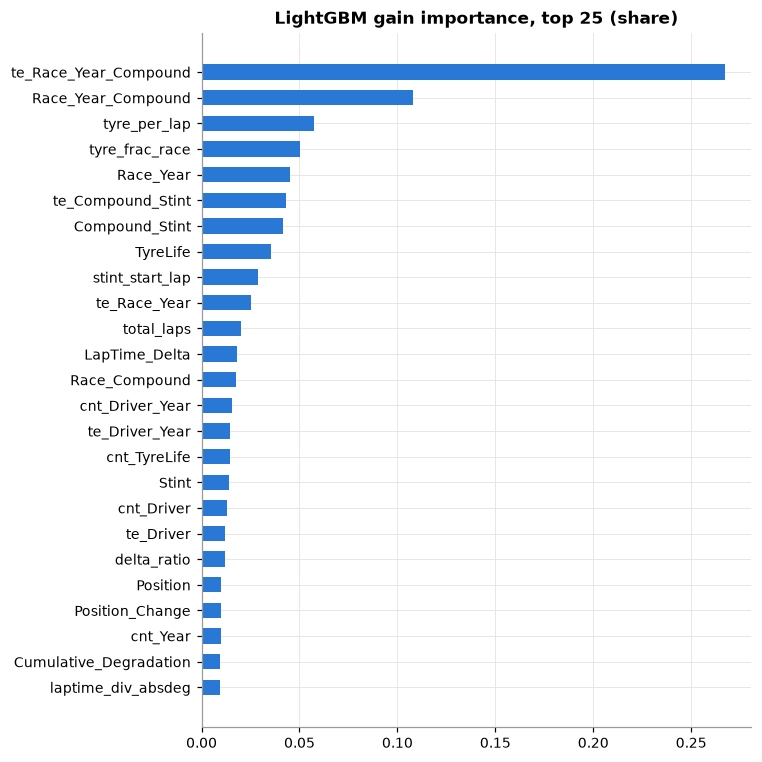

In [13]:
imp = pd.concat(importances, axis=1).mean(axis=1)
imp = (imp / imp.sum()).sort_values().tail(25)
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_title('LightGBM gain importance, top 25 (share)')
plt.tight_layout(); plt.show()

## 6. Submission

In [14]:
sub = sample[['id']].copy()
assert (sub['id'].values == test['id'].values).all()
sub[TARGET] = final_test
sub.to_csv('submission.csv', index=False)
print(sub.shape); display(sub.head())

(188165, 2)


,id,PitNextLap
0,439140,0.007373
1,439141,0.012067
2,439142,0.005103
3,439143,0.176733
4,439144,0.807732


In [15]:
def kaggle_cli(*args):
    # The CLI prints a UTF-8 progress bar; Windows' default cp1252 decoding crashes on it
    return subprocess.run(['kaggle', 'competitions', *args], capture_output=True, text=True,
                          encoding='utf-8', errors='replace')

SUBMIT = True   # set to False to re-run the notebook without submitting again
msg = f'{" + ".join(names)} | {final_name} | OOF AUC {final_oof_auc:.5f}'
if SUBMIT:
    out = kaggle_cli('submit', COMP, '-f', 'submission.csv', '-m', msg)
    print(out.stdout[-2000:], out.stderr[-300:])

99 submissions remaining today.
Successfully submitted to Predicting F1 Pit Stops  864k/5.11M [00:01<00:08, 535kB/s]
 28%|██▊       | 1.42M/5.11M [00:01<00:02, 1.35MB/s]
 57%|█████▋    | 2.89M/5.11M [00:01<00:00, 3.81MB/s]
 78%|███████▊  | 3.97M/5.11M [00:01<00:00, 5.25MB/s]
100%|██████████| 5.11M/5.11M [00:01<00:00, 6.56MB/s]
100%|██████████| 5.11M/5.11M [00:03<00:00, 1.73MB/s]



In [16]:
# Wait for scoring. The competition is closed, so the late submission shows both public and private scores.
for _ in range(30):
    subs = pd.read_csv(io.StringIO(kaggle_cli('submissions', '-c', COMP, '-v').stdout))
    if 'pending' not in str(subs.loc[0, 'status']).lower():
        break
    time.sleep(20)
display(subs.head(3))

,ref,fileName,date,description,status,publicScore,privateScore
0,56966316,submission.csv,2026-10-08 18:18:13.597000,lgb + lgb_no_driver + xgb + cat | logistic sta...,SubmissionStatus.COMPLETE,0.95235,0.95294
